In [ ]:
import cv2 as cv              # OpenCV计算机视觉库
import numpy as np            # NumPy数值计算库
import matplotlib.pyplot as plt  # Matplotlib绑图库

In [ ]:
def show(img):
    """自定义显示函数：自动判断灰度图或彩色图并正确显示"""
    if img.ndim == 2:  # 灰度图
        plt.imshow(img, cmap='gray')
    else:  # 彩色图，BGR转RGB
        img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
        plt.imshow(img)
    plt.show()

## 1.1 Prewitt算子

In [ ]:
# 读取灰度图用于边缘检测演示
img = cv.imread('pic/gift500x500.jpg', 0)
show(img)

In [ ]:
# Prewitt算子：手动定义x和y方向的卷积核
# kx检测垂直边缘，ky检测水平边缘
kx = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], dtype=np.float32)
ky = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]], dtype=np.float32)

# cv.filter2D()：用自定义核做卷积，cv.CV_64F表示输出为64位浮点（保留负值）
imgX = cv.filter2D(img, cv.CV_64F, kx)  # x方向梯度
imgY = cv.filter2D(img, cv.CV_64F, ky)  # y方向梯度

imgXY = np.sqrt(imgX**2 + imgY**2)      # 梯度幅值（L2范数）
imgXY2 = np.abs(imgX) + np.abs(imgY)    # 梯度幅值（L1范数，近似）

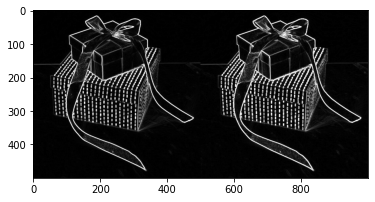

In [13]:
show(np.hstack([imgXY.clip(0,255), imgXY2.clip(0, 255)]))

## 1.2 Roberts算子

In [ ]:
# Roberts算子：2x2卷积核，对角线方向的梯度检测
kx = np.array([[-1, 0], [0, 1]], dtype=np.float32)
ky = np.array([[0, -1], [1, 0]], dtype=np.float32)

imgX = cv.filter2D(img, cv.CV_64F, kx)  # 对角线方向梯度
imgY = cv.filter2D(img, cv.CV_64F, ky)

In [ ]:
show(np.abs(imgX.clip(0,255)))

In [ ]:
# Roberts算子的梯度幅值计算
imgXY = np.sqrt(imgX**2 + imgY**2)   # L2范数
imgXY2 = np.abs(imgX) + np.abs(imgY) # L1范数

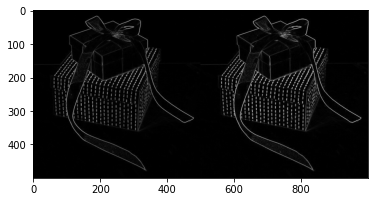

In [15]:
show(np.hstack([imgXY.clip(0,255), imgXY2.clip(0, 255)]))

## 2.1 Sobel-Feldman算子

dst = cv2.Sobel(src, ddepth, dx, dy [, ksize[, scale[, deltal[, borderType]]]] )

In [ ]:
# 读取新图片用于Sobel和Scharr算子演示
img = cv.imread('pic/bookshelf500x333.jpg', 0)
show(img)

In [ ]:
# cv.Sobel()：Sobel边缘检测，内置算子，比手动Prewitt更精确（中心权重更大）
# 参数：(图像, 输出深度, x方向阶数, y方向阶数)
imgX = cv.Sobel(img, cv.CV_16S, 1, 0)  # x方向梯度，CV_16S避免截断
imgY = cv.Sobel(img, cv.CV_16S, 0, 1)  # y方向梯度

imgXY = np.abs(imgX) + np.abs(imgY)    # 合成梯度幅值

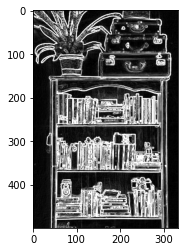

In [21]:
show(imgXY.clip(0, 255))

## 2.2 Scharr算子

In [ ]:
# cv.Scharr()：Scharr算子，比Sobel更精确的3x3梯度算子
imgX = cv.Scharr(img, cv.CV_64F, 1, 0)  # x方向梯度
imgY = cv.Scharr(img, cv.CV_64F, 0, 1)  # y方向梯度

imgXY = np.sqrt(imgX**2 + imgY**2)      # 梯度幅值

In [ ]:
# 并排显示：x方向梯度 | y方向梯度 | 合成梯度幅值
show(np.hstack([np.abs(imgX), np.abs(imgY), imgXY]))

## 3. Laplacian和loG算子

In [ ]:
img = cv.imread('pic/notebook500x333.jpg', 0)  # 读取灰度图用于Laplacian算子演示
show(img)

In [ ]:
img_lap = cv.Laplacian(img, cv.CV_64F)  # Laplacian算子：二阶导数检测边缘，CV_64F保留负值信息
show(np.abs(img_lap))  # 取绝对值显示，因为Laplacian输出有正负值

In [ ]:
img_blur = cv.GaussianBlur(img, (3,3), 1)  # 先做高斯平滑降噪，Laplacian对噪声敏感
img_log = cv.Laplacian(img_blur, cv.CV_64F)  # LoG（Laplacian of Gaussian）：先平滑再求二阶导
show(np.abs(img_log))

## 4. Canny边缘检测

cv2.Canny(img, threshold1, threshold2)
- threshold1: 表示双阈值算法中的最小阈值
- threshold2: 表示双阈值算法中的最大阈值

In [ ]:
img = cv.imread('pic/notebook500x333.jpg', 0)  # 读取灰度图用于Canny边缘检测演示
show(img)

In [ ]:
img_edge = cv.Canny(img, 20, 200)  # Canny边缘检测：双阈值算法，threshold1=20（低阈值），threshold2=200（高阈值）
show(img_edge)